# SpaceX Falcon 9 Landing Prediction - Exploratory Data Analysis (EDA)

This notebook covers **Section 1: Understand the Dataset** and **Section 2: Data Exploration (EDA)** of the SpaceX Falcon 9 first-stage landing success prediction project.

---

# 1. Understand the Dataset

The dataset is downloaded from Kaggle (`xjoannax88/spacex-falcon-9-launches`) and contains launch records for Falcon 9, including payload, launch sites, orbits, boosters, and landing outcomes.

### Target Variable
- **Booster landing**: This contains the outcome of the booster landing. We will derive our target variable **`Class`** from this, where `1` represents a successful landing (outcome containing the word "Success") and `0` represents an unsuccessful landing.

### Feature Classification & Descriptions:
1. **Numerical Features**:
   - `Flight No.`: Sequential number of the launch.
   - `Payload mass`: Weight of the payload in kilograms.
2. **Categorical Features**:
   - `Launch site`: The specific launch pad location (e.g. Cape Canaveral, KSC LC-39A, Vandenberg).
   - `Payload`: Name/description of the spacecraft carried.
   - `Orbit`: Target orbit type (e.g. LEO, GTO, ISS, MEO).
   - `Customer`: Entity/organization booking the launch.
   - `Launch outcome`: Overall status of the launch phase (e.g. Success, Failure).
   - `Version Booster`: Falcon 9 booster version/model variant.
   - `Booster landing`: Specific landing outcome text description.
3. **Date/Time Features**:
   - `Date`: Date of the launch.
   - `Time`: UTC launch time.

## 1.1 Imports and Settings

In [18]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="darkgrid", palette="muted")

## 1.2 Load Dataset

In [19]:
# Multi-path fallback resolution to handle running cell-by-cell inside notebooks/ or from project root
paths_to_try = [
    os.path.join('..', 'data', 'spacex_web_scraped.csv'),
    os.path.join('data', 'spacex_web_scraped.csv'),
    os.path.join('SPACEX-main', 'data', 'spacex_web_scraped.csv'),
    os.path.join('..', 'SPACEX-main', 'data', 'spacex_web_scraped.csv'),
    os.path.join('SPACEX-main', 'SPACEX-main', 'data', 'spacex_web_scraped.csv')
]

DATA_PATH = None
for p in paths_to_try:
    if os.path.exists(p):
        DATA_PATH = p
        break

if DATA_PATH is None:
    import glob
    candidates = glob.glob('**/spacex_web_scraped.csv', recursive=True)
    if not candidates:
        candidates = glob.glob('../**/spacex_web_scraped.csv', recursive=True)
    if candidates:
        DATA_PATH = candidates[0]

if DATA_PATH is None:
    raise FileNotFoundError("Could not find spacex_web_scraped.csv in any expected location.")

print(f"Found dataset at: {DATA_PATH}")
df = pd.read_csv(DATA_PATH)
df.head()

Found dataset at: ..\data\spacex_web_scraped.csv


,Flight No.,Launch site,Payload,Payload mass,Orbit,Customer,Launch outcome,Date,Time,Version Booster,Booster landing
0,1,Cape Canaveral,Dragon Spacecraft Qualification Unit,U,LEO,SpaceX,Success,4 June 2010,18:45,F9v1.0,Failure (parachute)
1,2,Cape Canaveral,SpaceX COTS Demo Flight 1,U,LEO,NASA,Success,8 December 2010,15:43,F9v1.0,Failure (parachute)
2,3,Cape Canaveral,SpaceX COTS Demo Flight 2,525 kg,LEO,NASA,Success,22 May 2012,07:44,F9 v1.0,No attempt
3,4,Cape Canaveral,SpaceX CRS-1,"4,700 kg",LEO,NASA,Success,8 October 2012,00:35,F9 v1.0,No attempt
4,5,Cape Canaveral,SpaceX CRS-2,"4,877 kg",LEO,NASA,Success,1 March 2013,15:10,F9 v1.0,No attempt


# 2. Exploratory Data Analysis (EDA)

Perform initial exploration to understand the properties of the data, extract the target variable, and check for missing values and duplicates.

## 2.1 Dataset Shape & Information

In [20]:
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nDataset Information:")
df.info()

Dataset Shape: 557 rows, 11 columns

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 557 entries, 0 to 556
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Flight No.       557 non-null    int64 
 1   Launch site      557 non-null    object
 2   Payload          554 non-null    object
 3   Payload mass     557 non-null    object
 4   Orbit            555 non-null    object
 5   Customer         542 non-null    object
 6   Launch outcome   557 non-null    object
 7   Date             557 non-null    object
 8   Time             557 non-null    object
 9   Version Booster  557 non-null    object
 10  Booster landing  557 non-null    object
dtypes: int64(1), object(10)
memory usage: 48.0+ KB


## 2.2 Handle Missing Values & Duplicates

In [21]:
print("Missing Values per Column:")
print(df.isnull().sum())

print(f"\nDuplicate Records: {df.duplicated().sum()}")

Missing Values per Column:
Flight No.          0
Launch site         0
Payload             3
Payload mass        0
Orbit               2
Customer           15
Launch outcome      0
Date                0
Time                0
Version Booster     0
Booster landing     0
dtype: int64

Duplicate Records: 0


## 2.3 Derive Target Class (`Class`)
We extract whether the booster landing was successful or not from the `Booster landing` column.

In [22]:
# Derive the Class target variable: 1 for landing success, 0 for failure
df['Class'] = df['Booster landing'].apply(lambda x: 1 if 'Success' in str(x) else 0)

print("Landing Class Counts:")
print(df['Class'].value_counts())

print("\nLanding Success Rate:")
print(f"{df['Class'].mean() * 100:.2f}%")

Landing Class Counts:
Class
1    508
0     49
Name: count, dtype: int64

Landing Success Rate:
91.20%


## 2.4 Class Distribution Visualization

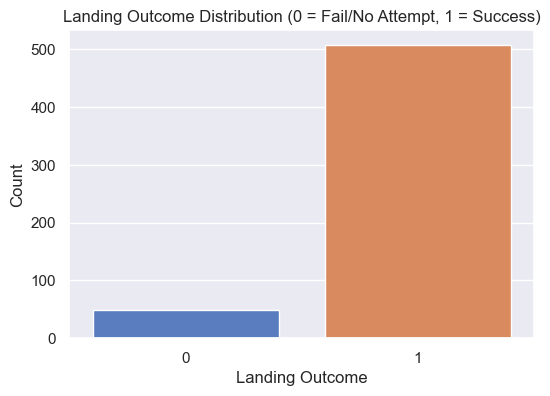

In [23]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Class', hue='Class', legend=False)
plt.title('Landing Outcome Distribution (0 = Fail/No Attempt, 1 = Success)')
plt.xlabel('Landing Outcome')
plt.ylabel('Count')
plt.show()

## 2.5 Clean Numerical Columns
The `Payload mass` column contains strings with 'kg', commas, and 'U' for unknown. We clean it and impute missing values with the median mass.

In [24]:
# Clean Payload mass
df['Payload mass'] = pd.to_numeric(df['Payload mass'].astype(str).str.replace('~', '').str.replace(',', '').str.replace('kg', '').str.strip(), errors='coerce')
# Impute missing payload mass with median
df['Payload mass'] = df['Payload mass'].fillna(df['Payload mass'].median())

print("Payload Mass Summary Statistics:")
print(df['Payload mass'].describe())

Payload Mass Summary Statistics:
count      557.000000
mean     12346.969479
std       5728.791451
min        325.000000
25%       6100.000000
50%      15525.000000
75%      16675.000000
max      17500.000000
Name: Payload mass, dtype: float64


## 2.6 Landing Success Rates by Launch Site, Orbit, and Booster Version

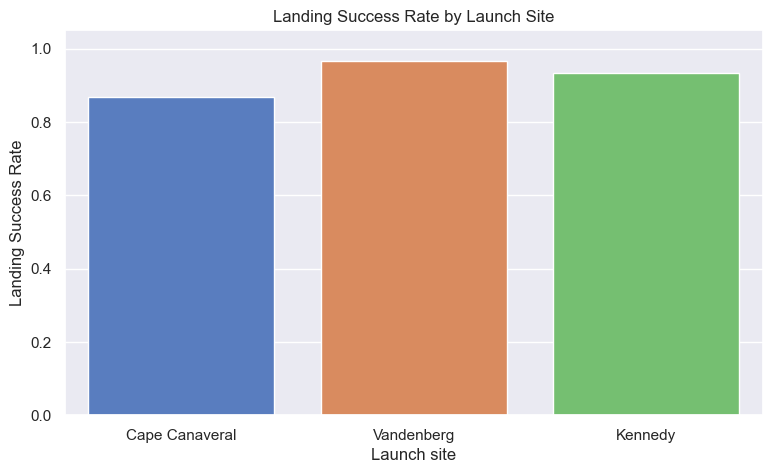

In [25]:
# 1. Success Rate by Launch Site
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x='Launch site', y='Class', errorbar=None, hue='Launch site', legend=False)
plt.title('Landing Success Rate by Launch Site')
plt.ylabel('Landing Success Rate')
plt.ylim(0, 1.05)
plt.show()

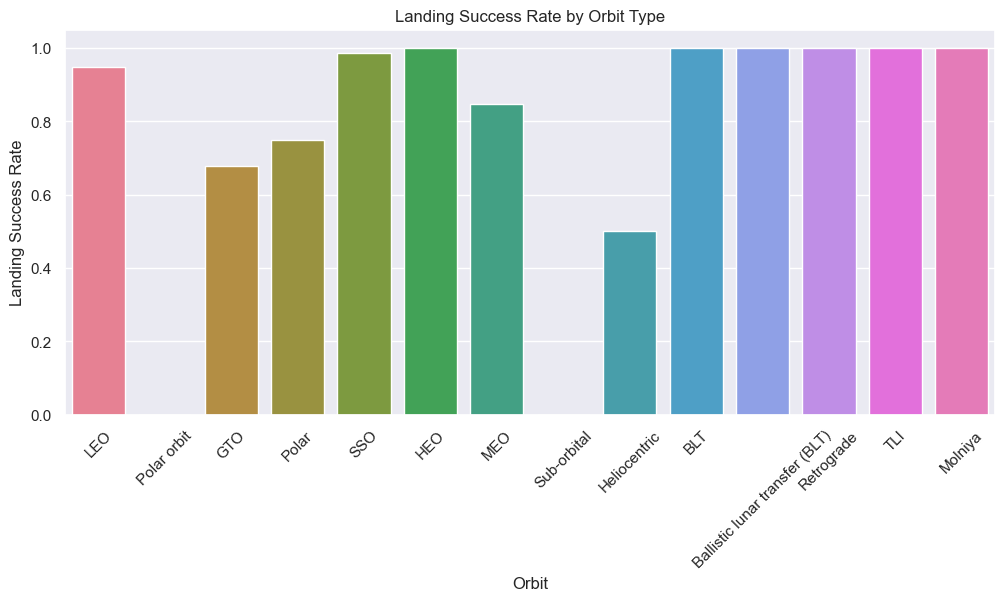

In [26]:
# 2. Success Rate by Orbit Type
plt.figure(figsize=(12, 5))
sns.barplot(data=df, x='Orbit', y='Class', errorbar=None, hue='Orbit', legend=False)
plt.title('Landing Success Rate by Orbit Type')
plt.ylabel('Landing Success Rate')
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.show()

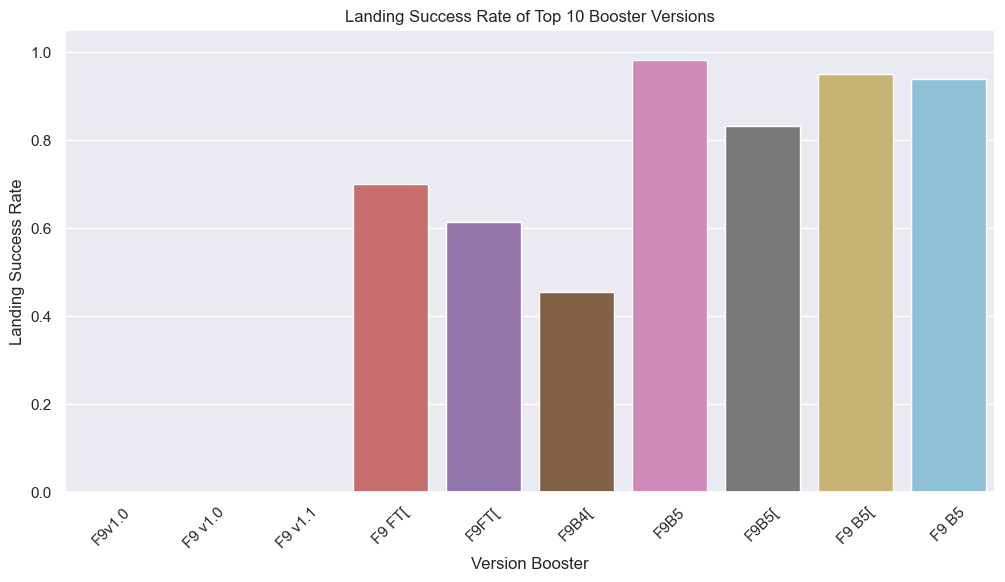

In [27]:
# 3. Success Rate by Booster Version
plt.figure(figsize=(12, 6))
# Look at top 10 booster versions
top_boosters = df['Version Booster'].value_counts().index[:10]
sns.barplot(data=df[df['Version Booster'].isin(top_boosters)], x='Version Booster', y='Class', errorbar=None, hue='Version Booster', legend=False)
plt.title('Landing Success Rate of Top 10 Booster Versions')
plt.ylabel('Landing Success Rate')
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.show()

## 2.7 Success Rate Trend Over Time (Launch Year)

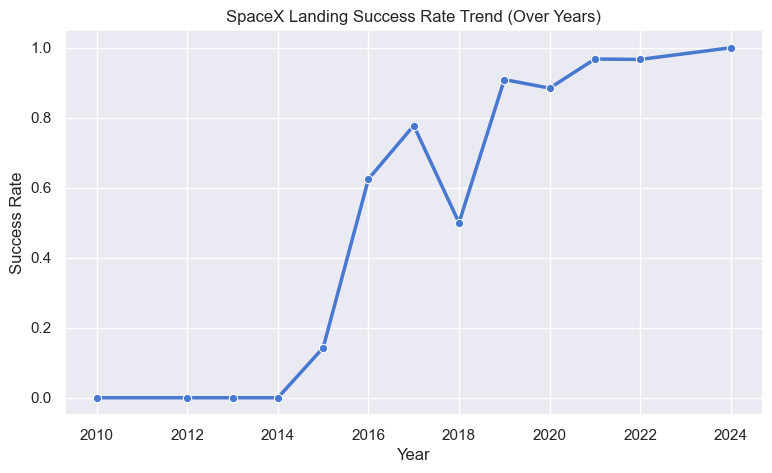

In [28]:
# Extract year from Date
df['Year'] = pd.to_datetime(df['Date'], errors='coerce').dt.year

# Plot success rate over years
yearly_stats = df.groupby('Year')['Class'].mean().reset_index()

plt.figure(figsize=(9, 5))
sns.lineplot(data=yearly_stats, x='Year', y='Class', marker='o', linewidth=2.5)
plt.title('SpaceX Landing Success Rate Trend (Over Years)')
plt.xlabel('Year')
plt.ylabel('Success Rate')
plt.ylim(-0.05, 1.05)
plt.show()

## 2.8 Payload Mass Distribution

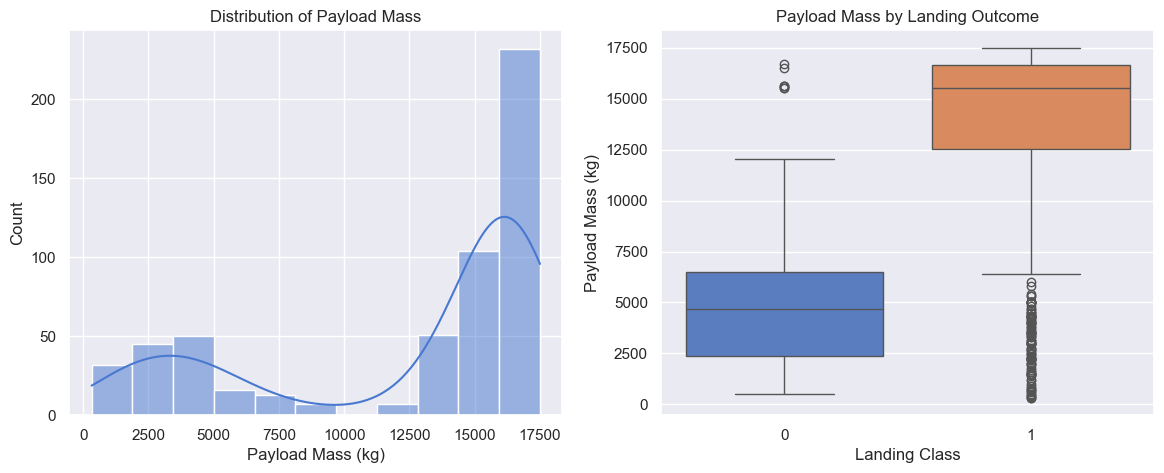

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of payload mass
sns.histplot(data=df, x='Payload mass', kde=True, ax=axes[0])
axes[0].set_title('Distribution of Payload Mass')
axes[0].set_xlabel('Payload Mass (kg)')

# Boxplot of payload mass by Class
sns.boxplot(data=df, x='Class', y='Payload mass', hue='Class', legend=False, ax=axes[1])
axes[1].set_title('Payload Mass by Landing Outcome')
axes[1].set_xlabel('Landing Class')
axes[1].set_ylabel('Payload Mass (kg)')

plt.show()

## 2.9 Flight Number vs. Payload Mass Scatter Plot

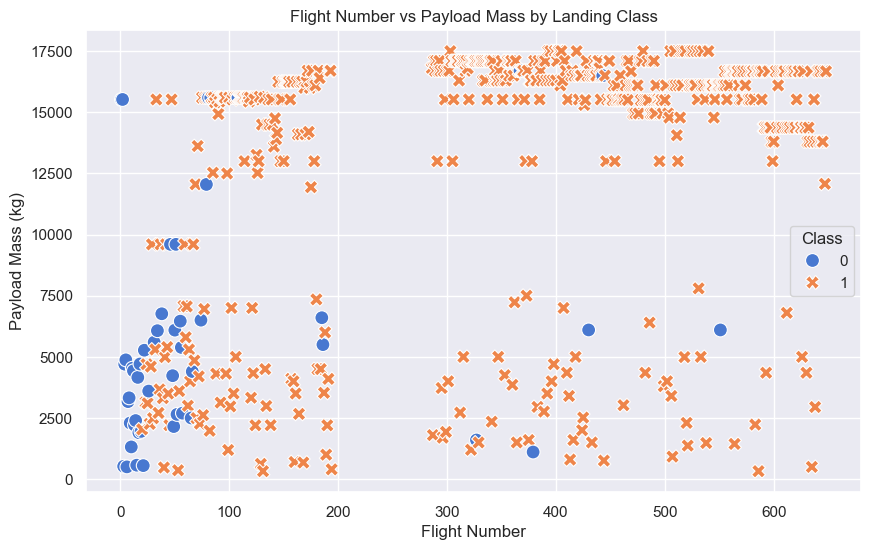

In [30]:
df['Flight No.'] = pd.to_numeric(df['Flight No.'], errors='coerce')

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Flight No.', y='Payload mass', hue='Class', style='Class', s=100)
plt.title('Flight Number vs Payload Mass by Landing Class')
plt.xlabel('Flight Number')
plt.ylabel('Payload Mass (kg)')
plt.show()

## 2.10 Correlation Matrix Heatmap

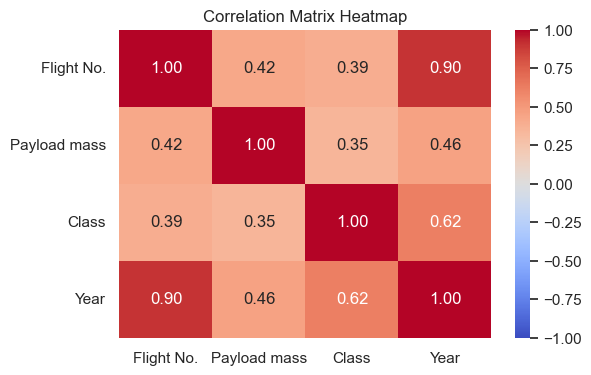

In [31]:
plt.figure(figsize=(6, 4))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap')
plt.show()